In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import special

/home/soumyajit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import scienceplots
plt.style.use("science")

%config InlineBackend.figure_format = 'retina'
mpl.rcParams['figure.dpi']=120 #default is 72. 

In [3]:
prob_data = pd.read_csv("survival_probability_new.csv",sep=",")

prob_data.head()

,x (L/E),P_ee,P_ee_err_min,P_ee_err_max,P_ee_err
0,23.261848,0.588141,0.528376,0.649788,0.121412
1,28.602149,0.639309,0.585662,0.695780,0.110118
2,30.937424,0.687725,0.629842,0.748901,0.119059
3,32.780057,0.866976,0.795917,0.935682,0.139765
4,34.497508,0.722935,0.662700,0.783642,0.120941


In [4]:
neutrino_flux = pd.read_csv("neutrino_flux.txt", sep="\s+")

L_reactor = neutrino_flux['Distance_km'].to_numpy()[:16] # Only Japan reactors
Phi = neutrino_flux['Flux_cm2_s'].to_numpy()[:16] # Only Japan reactors

L_avg = np.sum(L_reactor*Phi)/np.sum(Phi)

In [5]:
def P_ee_dark(dm21, theta12, theta13, L, E):
    
    #Three-flavor vacuum survival probability for reactor antineutrinos
    
    dm31=2.50e-3
    
    dm32 = dm31 - dm21

    # E_GeV = E # / 1000.0   # convert MeV → GeV

    Delta21 = 1.267 * dm21 * L * 1e3 / E # To make the unit of L meter (m). 
    Delta31 = 1.267 * dm31 * L * 1e3 / E
    Delta32 = 1.267 * dm32 * L * 1e3 / E

    s12, c12 = np.sin(theta12), np.cos(theta12)
    s13, c13 = np.sin(theta13), np.cos(theta13)

    Pee = (
        1
        - 2 * (c12**2 * c13**2) * (s12**2 * c13**2) * (1- special.jv(0, Delta21)* np.cos(Delta21))
        - 2 * (c12**2 * c13**2) * (s13**2)        * (1- special.jv(0, Delta31)* np.cos(Delta31))
        - 2 * (s12**2 * c13**2) * (s13**2)        * (1- special.jv(0, Delta32)* np.cos(Delta32))
    )
    
    return Pee

In [6]:
def P_ee_flux_weighted(x_values, dm21, theta12, theta13):
    
    x_values = np.asarray(x_values)
    
    P_ee_weighted= np.zeros_like(x_values,dtype=float)

    for i,x in enumerate(x_values):  

        E = 180/x # in MeV

        Pee= np.array([P_ee_dark(dm21, theta12, theta13, L, E) for L in L_reactor])

        P_ee_weighted[i]= np.sum(Pee * Phi)/np.sum(Phi)

    return P_ee_weighted

In [7]:
def P_ee_fw_binned(x_centers, dx, dm21, theta12, theta13):

    x_centers= np.asarray(x_centers)
    Pee_binned= np.zeros_like(x_centers, dtype=float)

    # dx= np.median(np.diff(x_centers))

    for i, xc in enumerate(x_centers):

        x_samples= np.linspace(xc-dx/2,xc+dx/2,20)
        
        Pee_samples = []
        for x in x_samples:
            E = 180 / x
            Pee_reactors = np.array([
                P_ee_dark(dm21, theta12, theta13, L, E)
                for L in L_reactor
            ])
            Pee_samples.append(np.sum(Phi * Pee_reactors) / np.sum(Phi))

        Pee_binned[i] = np.mean(Pee_samples)

    return Pee_binned

In [8]:
x = prob_data["x (L/E)"].to_numpy()
P_data = prob_data["P_ee"].to_numpy()
P_err = prob_data["P_ee_err"].to_numpy()

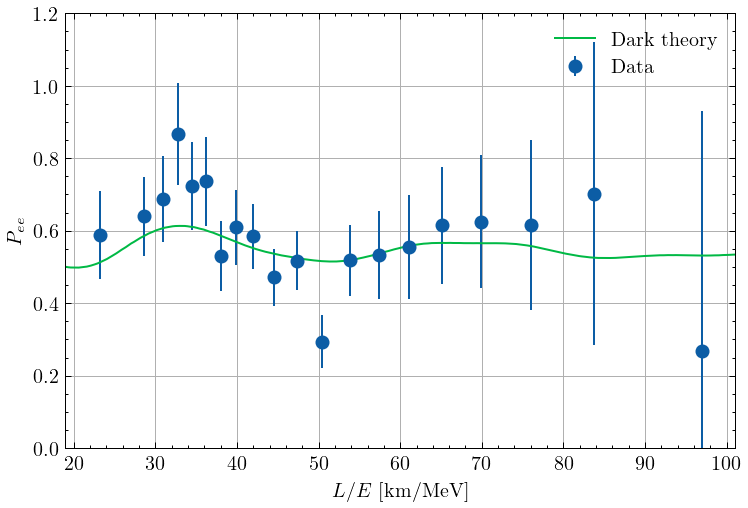

In [9]:
# theory prediction at bin centres
dm21_test = 8.72e-5
th12_test = 0.78
th13_test = 0.09

x_arr=np.linspace(19,101,500)
P_th = P_ee_flux_weighted(x_arr, dm21_test, th12_test, th13_test)

plt.errorbar(x, P_data, yerr=P_err, fmt='o', label='Data')
plt.plot(x_arr, P_th, label='Dark theory')
plt.xlabel(r'$L/E$ [km/MeV]')
plt.ylabel(r'$P_{ee}$')

plt.xlim(19,101)
plt.ylim(0,1.2)
plt.legend()
plt.grid()
plt.show()

In [12]:
def chi2_dark(params):
    dx=np.median(np.diff(x))

    dm21, theta12, theta13 = params
    P_th = P_ee_fw_binned(x, dx, dm21, theta12, theta13)

    chi2 = np.sum(((P_data - P_th)/P_err)**2)

    return chi2

In [13]:
from scipy.optimize import minimize

initial = [7.5e-5, 0.6, 0.15]

res = minimize(chi2_dark, initial)

print(res.x)

[1.25199231e-02 3.83300628e-06 6.40619315e-01]


In [45]:
cov = res.hess_inv        # covariance matrix
errors = np.sqrt(np.diag(cov))

print("Best-fit parameters:", res.x)
print("Parameter errors:", errors)

Best-fit parameters: [ 3.37091675e-01  6.93078668e-08 -6.40729068e-01]
Parameter errors: [2.18667157e-04 8.67626841e-01 3.41324072e-02]


In [25]:
res.message

'Optimization terminated successfully.'

### Parameter reconstruction using UltraNest

#### Dark mass hypothesis:

  $$ P_{ee} = 1 - 2 \cos^{4}\theta_{13}\,\sin^{2}\theta_{12}\,\cos^{2}\theta_{12}\left[1- J_{0}\!\left(X_{21D}\right) \cos\!\left(X_{21D}\right) \right] - 2 \cos^{2}\theta_{13}\,\sin^{2}\theta_{13}.
  $$

Where, $$X_{ijD}= \frac{\Delta m_{ijD}^2\,L}{4 E},$$ where $m_\phi$ is the mass of ULDM, $J_0(z)$ is the bessel function of first kind.

In [15]:
param_names = [r'$\Delta m^{2}_{21}$', r'$\theta_{12}$', r'$\theta_{13}$']

In [16]:
import scipy.stats

def my_prior_transform(cube): # The prior list for parameters
    params = cube.copy()

    # dm21 varies between [1-15]* 10^(-5) eV^2
    hi= 15
    lo= 1
    params[0] = (cube[0] * (15 - 1) + 1)*1e-5

    # theta_12 varies within [0-1]
    params[1] = cube[1]

    # theta_13 varies within [0-1]
    params[2] = cube[2]

    return params

In [17]:
from numpy import log

dx=np.median(np.diff(x))

def my_likelihood(params):
    dm21, theta12, theta13 = params
    
    # compute intensity at every x position according to the model
    P_th = P_ee_fw_binned(x,dx,dm21, theta12, theta13)
    
    # compare model and data with gaussian likelihood:
    chi2 = np.sum(((P_th - P_data)/P_err)**2)
    like = -0.5 * chi2
    return like

In [18]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)

In [19]:
result = sampler.run(show_status=False, viz_callback=None)
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...
[ultranest] Explored until L=-9  
[ultranest] Likelihood function evaluations: 13713
[ultranest]   logZ = -13.11 +- 0.0571
[ultranest] Effective samples strategy satisfied (ESS = 2155.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.05 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.06, need <0.5)
[ultranest]   logZ error budget: single: 0.08 bs:0.06 tail:0.01 total:0.06 required:<0.50
[ultranest] done iterating.

logZ = -13.109 +- 0.099
  single instance: logZ = -13.109 +- 0.079
  bootstrapped   : logZ = -13.109 +- 0.099
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $\Delta m^{2}_{21}$ : 0.000010│▁▁▂▂▄▆▆▃▁▁▁▁▁▁▁▁▁▁▁▂▅▇▆▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁│0.000150    0.000065 +- 0.000033
    $\theta_{12}$       : 0.00  │▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▂▂▂▃▃▄▄▆▆▆▆▇▇▆▇▇▆▅▅▄▃│1.00      0.70 +- 0.22
    $\theta_{13}$       : 0.00  │▅▅▆▇▇▇▇▆▅▆

In [20]:
parameters=result['maximum_likelihood']['point']

parameters

[8.868633329106187e-05, 0.7827618690289171, 0.07192131651384576]

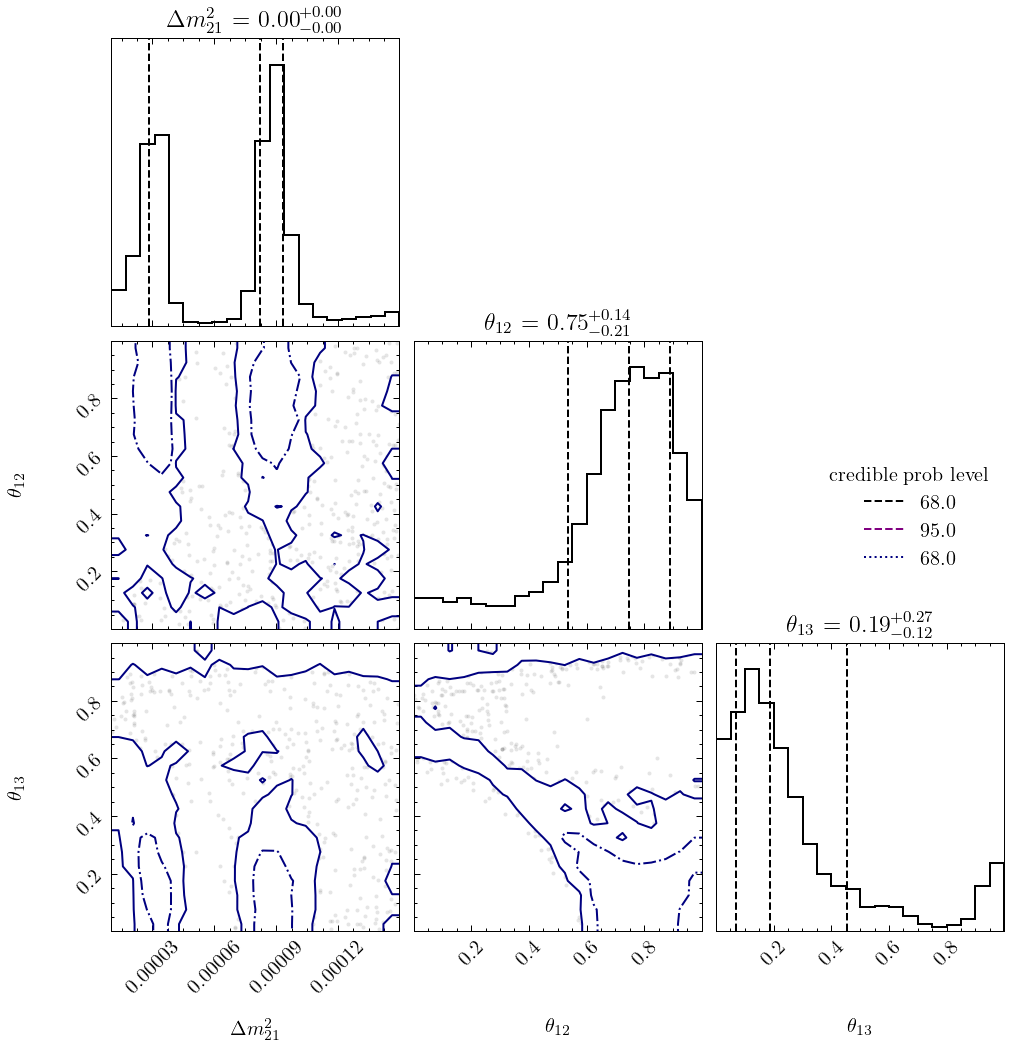

In [22]:
from ultranest.plot import cornerplot
fig= cornerplot(result,
                plot_datapoints=True, 
                levels=[0.68, 0.95],
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                color='black');
# plt.tight_layout()
plt.show()

In [23]:
dm21_dark= result["weighted_samples"]["points"][:,0]
theta12_dark= result["weighted_samples"]["points"][:,1]
theta13_dark= result["weighted_samples"]["points"][:,2]

### Playing with UltraNest

In [38]:
result.keys()

dict_keys(['niter', 'logz', 'logzerr', 'logz_bs', 'logz_single', 'logzerr_tail', 'logzerr_bs', 'ess', 'H', 'Herr', 'posterior', 'weighted_samples', 'samples', 'maximum_likelihood', 'ncall', 'paramnames', 'logzerr_single', 'insertion_order_MWW_test'])

In [80]:
result['logz'],result['logzerr'],result['ess'],result['H']

(-12.05913092519483,
 0.14880025532590793,
 1982.2938446390567,
 4.055758366523582)

In [57]:
result['weighted_samples'].keys()

dict_keys(['upoints', 'points', 'weights', 'logw', 'bootstrapped_weights', 'logl'])

In [88]:
weighted_samples= result['weighted_samples']
weighted_samples['weights']

array([1.65643970e-69, 8.41611773e-68, 6.03877266e-62, ...,
       2.54985004e-05, 2.55038430e-05, 2.55059301e-05])

In [82]:
1/sum(weighted_samples['weights']**2) ## should be equal to ess

1982.293844639141

In [53]:
import os
os.cpu_count()

4

In [61]:
import inspect
print(inspect.signature(ultranest.ReactiveNestedSampler))

(param_names, loglike, transform=None, derived_param_names=[], wrapped_params=None, resume='subfolder', run_num=None, log_dir=None, num_test_samples=2, draw_multiple=True, num_bootstraps=30, vectorized=False, ndraw_min=128, ndraw_max=65536, storage_backend='hdf5', warmstart_max_tau=-1)


In [59]:
sampler.num_workers

AttributeError: 'ReactiveNestedSampler' object has no attribute 'num_workers'